# Quadcopter EKF — State Estimation for Figure-8 Trajectory Tracking

*An estimation-control companion to the Cascade-PID example.*

This notebook extends the <a href="https://c4dynamics.github.io/c4dynamics/programs/pid_cascade/quadcopter_pid.html" target="_blank">Quadcopter Cascade-PID figure-8 example</a> so that the quadcopter no longer has access to its true state. Instead it carries an
**Extended Kalman Filter (EKF)** that reconstructs the full 12-state vector from
**noisy GPS and IMU measurements**, and the cascade controller closes the loop on
that *estimate*. The result is a complete, realistic **estimation-control pipeline**.

## Goal

Show how to build a framework-native EKF in c4dynamics that:

- propagates the **same** nonlinear rigid-body dynamics used by the truth model
  during the *predict* stage, and
- corrects the estimate with **GPS** and **IMU** (gyroscope + accelerometer) plus a
  **magnetometer** during the *update* stage,

and to demonstrate, under realistic sensing (white noise + biases), how well the
vehicle tracks a figure-8 while flying on estimated state.

## Notebook Overview

| Section | Content |
|---|---|
| 1. Setup | imports and the reusable modules |
| 2. The estimation problem | truth vs. estimate, the closed-loop architecture |
| 3. Vehicle & trajectory | the 12-state model and figure-8 reference (reused) |
| 4. Process model | the shared dynamics, the Jacobian, the *predict* step |
| 5. Sensors | GPS / IMU / magnetometer, noise, bias, measurement models |
| 6. The EKF | the *predict*/*update* cycle, gating, adaptive noise |
| 7. Simulation | configuration and the single closed-loop run |
| 8. Results | true-vs-estimated states, ±2σ bands, NEES, RMSE |
| 9. Conclusions | what to expect, and where to take it next |

Everything reusable lives in two modules — `quad_pid_utils.py` (plant + control,
unchanged from the Cascade-PID example) and `ekf.py` (sensors + estimator). This
notebook only configures them and shows the results.

## 1. Setup

In [3]:
import sys
# On Google Colab, install c4dynamics and fetch the example modules:
if 'google.colab' in sys.modules:
    !pip install -q c4dynamics

import numpy as np
import matplotlib.pyplot as plt
import c4dynamics as c4d
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import ekf                                # sensors + EKF (this example's estimation module)
from quad_pid_utils import run_fig8_pid   # plant + cascade-PID controller (reused)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 kB 5.0 MB/s eta 0:00:00


## 2. The Estimation Problem

In the Cascade-PID example the controller read the vehicle's **true** state directly.
A real autopilot never sees truth, it only sees noisy sensors. The job of the EKF is
to fuse those measurements with a dynamics model into a best estimate $\hat{x}$, which
the controller then uses in place of truth.

Two `state` objects run side by side on a single time loop:

- a **truth** `c4d.rigidbody`, propagated with the full nonlinear dynamics, and
- an **estimate** `ekf.ekf12` (a subclass of `c4d.filters.ekf`), updated from sensors.

They are coupled **only** through the sensors (truth → measurement → estimate) and
through control (estimate → controller → rotors → truth):

Because the framework EKF is itself a `state` object, the estimate stores its own
history (`store`/`data`) and exposes named components (`est.phi`), so the controllers
read it exactly as they read the truth rigidbody, no adapter is required.

## 3. Vehicle & Trajectory

The vehicle is the same 12-state quadcopter as the Cascade-PID example,

$$ x = [\,x, y, z,\; v_x, v_y, v_z,\; \phi, \theta, \psi,\; p, q, r\,]^\top, $$

and the reference is the same three-phase figure-8 (take-off → Lissajous → landing).
We reuse those configuration blocks verbatim.

In [4]:
quadcopter = {
    'm'  : 0.468, 'g'  : 9.81,  'l'  : 0.225, 'kT' : 2.98e-6, 'kQ' : 0.0382,
    'Ixx': 4.856e-3, 'Iyy': 4.856e-3, 'Izz': 8.801e-3,
    'Ax' : 0.30, 'Ay' : 0.30, 'Az' : 0.25, 'Ar' : 0.20, 'IR' : 3.357e-5,
}

trajectory = {
    'A': 4.0, 'B': 2.0, 'omega': 0.1, 'z_ref': 1.5, 't_end': 90.0,
}

controller = {
    'Kp_p': 0.80, 'Ki_p': 0.0001, 'Kd_p': 0.010,
    'Kp_q': 0.80, 'Ki_q': 0.0001, 'Kd_q': 0.010,
    'Kp_r': 0.60, 'Ki_r': 0.0001, 'Kd_r': 0.008,
    'Kp_phi': 6.0, 'Ki_phi': 0.0001, 'Kd_phi': 0.80, 'AW_phi': 0.5,
    'Kp_theta': 6.0, 'Ki_theta': 0.0001, 'Kd_theta': 0.80, 'AW_theta': 0.5,
    'Kp_psi': 4.0, 'Ki_psi': 0.5, 'Kd_psi': 0.40, 'AW_psi': 0.5,
    'Kp_x': 0.80, 'Ki_x': 0.00, 'Kd_x': 0.50, 'AW_x': 0.5,
    'Kp_y': 1.00, 'Ki_y': 0.00, 'Kd_y': 0.70, 'AW_y': 0.5,
    'Kp_z': 8.0, 'Ki_z': 8.0, 'Kd_z': 1.50, 'AW_z': 3.0,
    'Kff_x': 0.35, 'Kff_y': 0.40,
    'N_rate': 50, 'omega_max': 1000.0, 'T_max_factor': 4, 'T_min': 0.0,
    'att_cmd_limit': 0.314, 'yaw_rate_limit': 1.0,
}

simulation = {'dt': 0.005, 'tf': 90.0}

## 4. Process Model — the *predict* stage

The EKF's process model **is** the truth dynamics, $\dot{x}=f(x,u)$ — the very same
`quad_pid_utils.dynamics`. This "one model, two roles" is the heart of the design:
the truth integrates $f$ with `solve_ivp`, while the EKF integrates the same $f$ with
a single Euler step and propagates the covariance through its Jacobian.

**State prediction (Euler):**
$$ \hat{x}_k^- = \hat{x}_{k-1}^+ + \Delta t\, f(\hat{x}_{k-1}^+, u). $$

**Covariance prediction (2nd-order discretization):**
$$ F = \left.\frac{\partial f}{\partial x}\right|_{\hat{x}}, \qquad
   F_d = I + \Delta t\,F + \tfrac{1}{2}\Delta t^2 F^2, \qquad
   P_k^- = F_d\,P_{k-1}^+\,F_d^\top + Q. $$

The Jacobian $F$ is computed in closed form by `ekf.jacobian_F` (kinematics, drag,
thrust projection, Euler-angle kinematics, and Euler's rotational equations including
the rotor gyroscopic coupling). The process noise $Q$ is increased on the velocity
channel during high-acceleration segments (adaptive $Q$).

In c4dynamics this maps directly onto `ekf.predict(F=F_d, fx=f, dt=dt, Q=Q)`.

## 5. Sensors — the measurements

| Sensor | Observes | Rate | Model |
|---|---|---|---|
| GPS | position $x,y,z$ | 10 Hz | linear |
| IMU — gyro | body rates $p,q,r$ | 200 Hz | linear |
| IMU — accel | specific force $a_x,a_y$ | 200 Hz | **nonlinear** |
| Magnetometer | heading $\psi$ | 50 Hz | linear (angle-wrapped) |

Each sensor maps the **true** state to a noisy, biased measurement and is the only
path by which truth reaches the estimator. The accelerometer is the one nonlinear
measurement: at near-hover it senses the gravity projection
$$ h(x) = \begin{bmatrix} g\sin\theta \\ -g\sin\phi\cos\theta \end{bmatrix}, $$
linearised each step by $H_{\text{acc}}=\partial h/\partial x$. The *simulator* also
adds the vehicle's translational acceleration (what a real IMU sees) which the model
$h(x)$ omits; that mismatch is absorbed by an inflated accelerometer $R$.

The white-noise levels and the (optional) constant biases are part of the EKF
configuration block below.

## 6. The Extended Kalman Filter — the *update* stage

For each sensor the EKF forms the innovation, tests it, and corrects:

$$ y = z - h(\hat{x}), \qquad S = H P H^\top + R, \qquad
   \text{NIS} = y^\top S^{-1} y. $$

**Innovation gating.** If $\text{NIS}$ exceeds the $\chi^2$ 95% threshold for that
sensor's dimension, the measurement is rejected as an outlier. Otherwise:

$$ K = P H^\top S^{-1}, \qquad
   \hat{x}^+ = \hat{x}^- + K y, \qquad
   P^+ = (I-KH)P^-. $$

Two refinements are applied as a thin layer over the framework `update`:

- **Adaptive GPS $R$** — when GPS innovations grow, $R_{\text{gps}}$ is inflated so the
  filter down-weights degraded measurements (a Mehra-style two-phase scheme).
- **Angle-wrapped yaw** — the magnetometer innovation is wrapped to $[-\pi,\pi]$ so a
  yaw estimate near $\pm\pi$ is corrected toward the measurement, not away from it.

All of this is encapsulated in `ekf.ekf12`; the controllers and the loop never see it.

## 7. Simulation

The estimation block - process noise $Q$, measurement noise $R$, initial covariance
$P_0$, the initial-estimate offset, the injected sensor noise, and the sensor rates
is provided as data, the estimation analogue of the controller-gain block. Start from
the reference block and tune as needed.

In [5]:
ekf_cfg = ekf.default_ekf_config()    # reference EKF noise / init block
ekf_cfg

{'Q': array([[2.50e-05, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
         0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
        [0.00e+00, 2.50e-05, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
         0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
        [0.00e+00, 0.00e+00, 6.40e-05, 0.00e+00, 0.00e+00, 0.00e+00,
         0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
        [0.00e+00, 0.00e+00, 0.00e+00, 4.00e-04, 0.00e+00, 0.00e+00,
         0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
        [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 4.00e-04, 0.00e+00,
         0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
        [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 6.25e-04,
         0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
        [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
         6.40e-05, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
        [0.00e+00, 0.0

In [6]:
config = {
    'quad'      : quadcopter,
    'trajectory': trajectory,
    'controller': controller,
    'sim'       : simulation,
}

# One closed loop: truth flies on the EKF estimate; the EKF runs on GPS/IMU.
truth, est, diag = ekf.run_fig8_ekf(config, ekf_cfg)

EKF closed-loop  |  tf = 90.0 s  |  dt = 0.005 s
EKF closed-loop complete.


## 8. Results

### What to expect

- **Position** ($x,y,z$): tracked to a few tens of centimetres - GPS at 10 Hz bounds
  the position error while the dynamics bridges the gaps between fixes.
- **Attitude** ($\phi,\theta,\psi$): roll/pitch are observed by the accelerometer at
  200 Hz and stay within a couple of degrees; yaw relies on the 50 Hz magnetometer.
- **±2σ bands** should contain the truth most of the time, a sign the covariance is
  neither over- nor under-confident.
- **NEES** (normalised estimation error squared) should hover around $n=12$, the mark
  of a *consistent* filter.

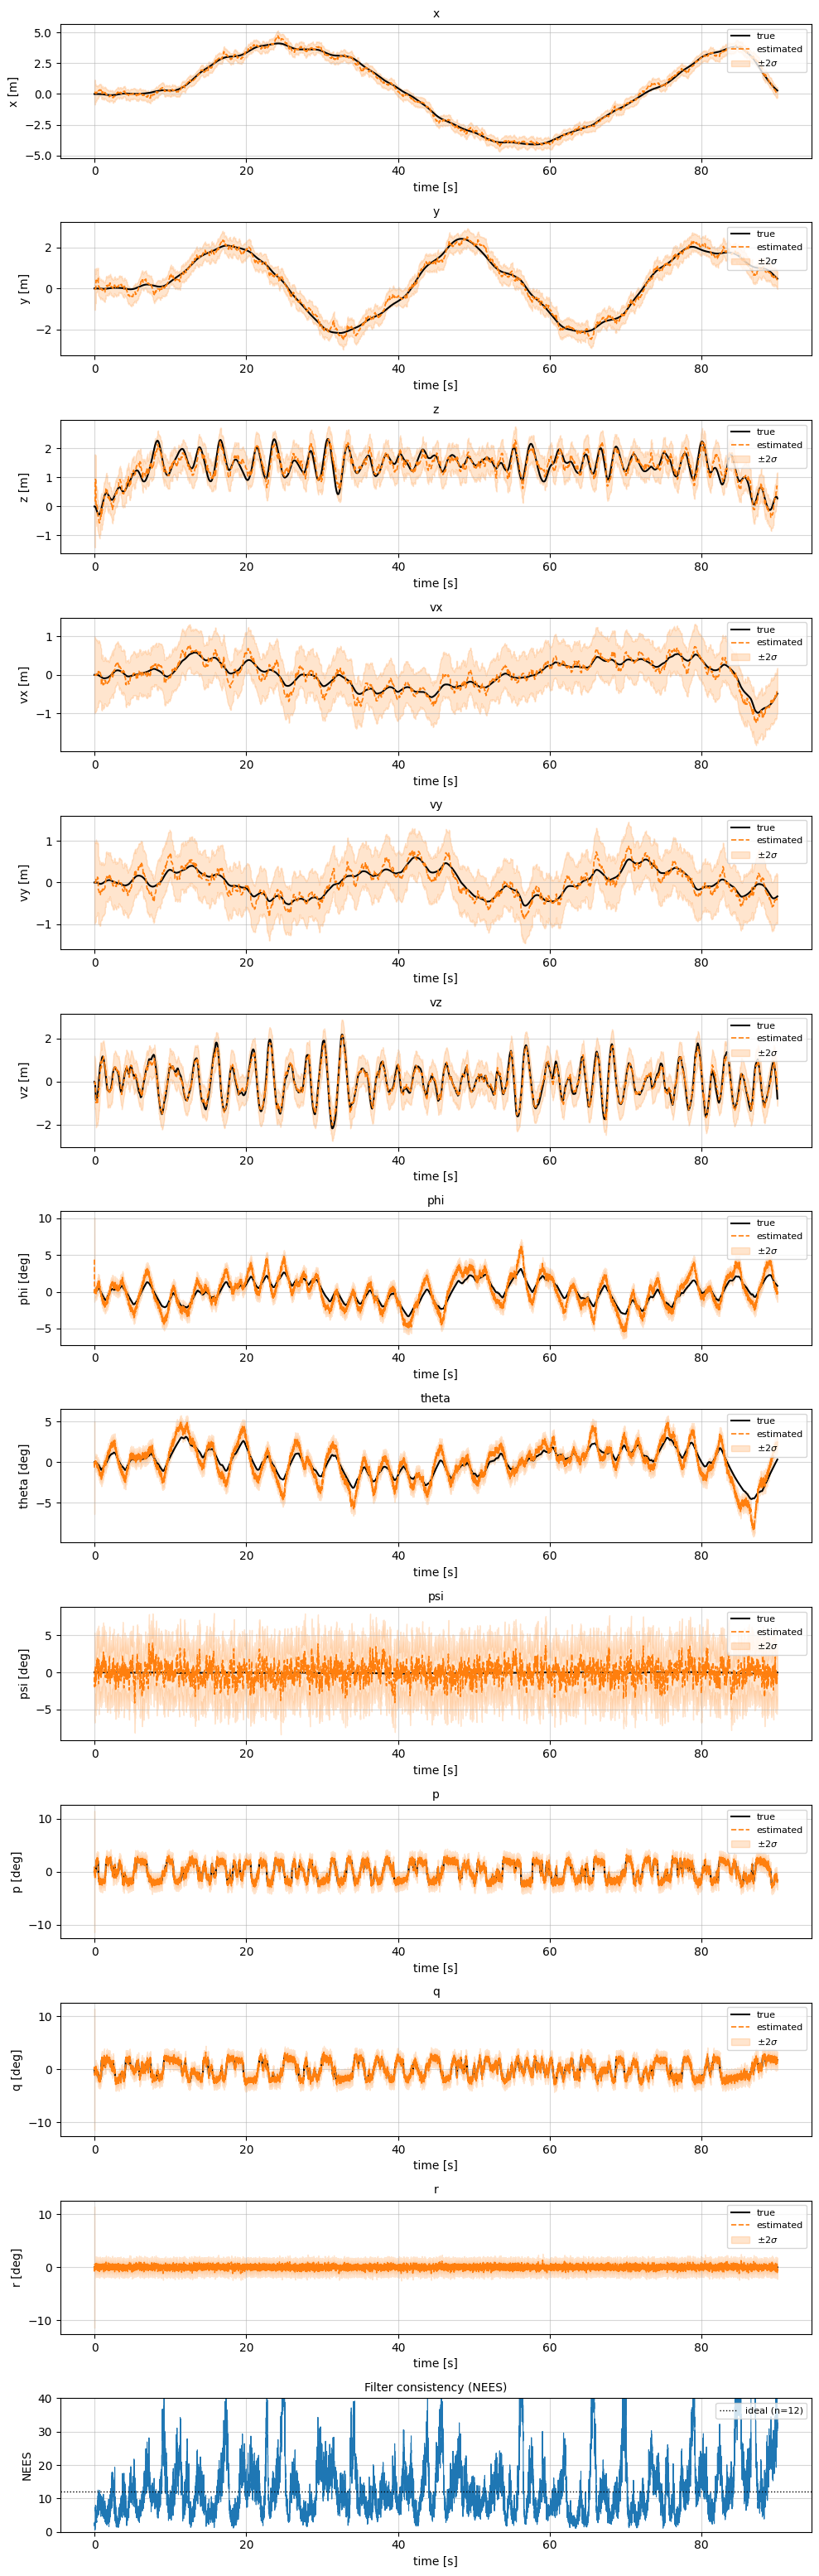

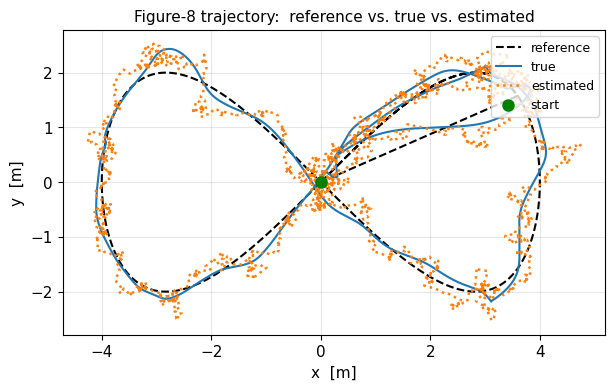

In [7]:
fig = ekf.plot_estimation(truth, est, diag, states=('x','y','z','vx','vy','vz','phi','theta','psi','p','q','r'))
fig8 = ekf.plot_trajectory(truth, est, config)

### Tracking metrics

Per-state RMSE between truth and estimate over the figure-8 phase, plus the mean
NEES. NEES near 12 indicates the reported covariance is statistically honest.

In [8]:
metrics = ekf.compute_metrics(truth, est, diag)

state           RMSE
--------------------
x             0.1695
y             0.1608
z             0.1813
vx            0.1279
vy            0.1292
vz            0.1340
phi           0.0162
theta         0.0149
psi           0.0211
p             0.0056
q             0.0055
r             0.0057
--------------------
NEES           12.59   (ideal ~ 12)


## 9. Conclusions & Possible Extensions

The same figure-8 that the Cascade-PID example flew on perfect state is now flown on a
state **estimated** from noisy GPS and IMU — a complete estimation-control pipeline,
built entirely on c4dynamics abstractions (`c4d.rigidbody`, `c4d.filters.ekf`, the
sensor pattern, and `store`/`data`).

Natural next steps:

- **Sensor biases & bias estimation** — turn on the constant biases in the sensors and
  augment the state to estimate them online.
- **GPS velocity** — add a lower-rate velocity measurement to tighten the velocity
  channel.
- **Waypoint / trajectory generation** — replace the analytic figure-8 with a planner.
- **Degraded sensing** — stress the filter with GPS dropouts or inflated noise and
  watch the adaptive $R$ and innovation gate respond.

## Demos

In [1]:
from ekf import imu, gps, magnetometer

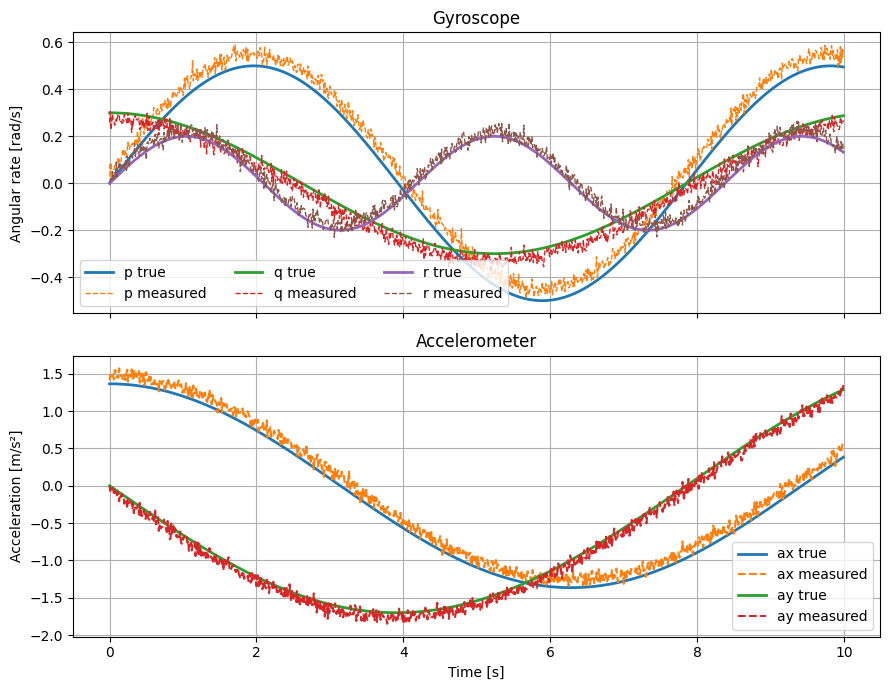

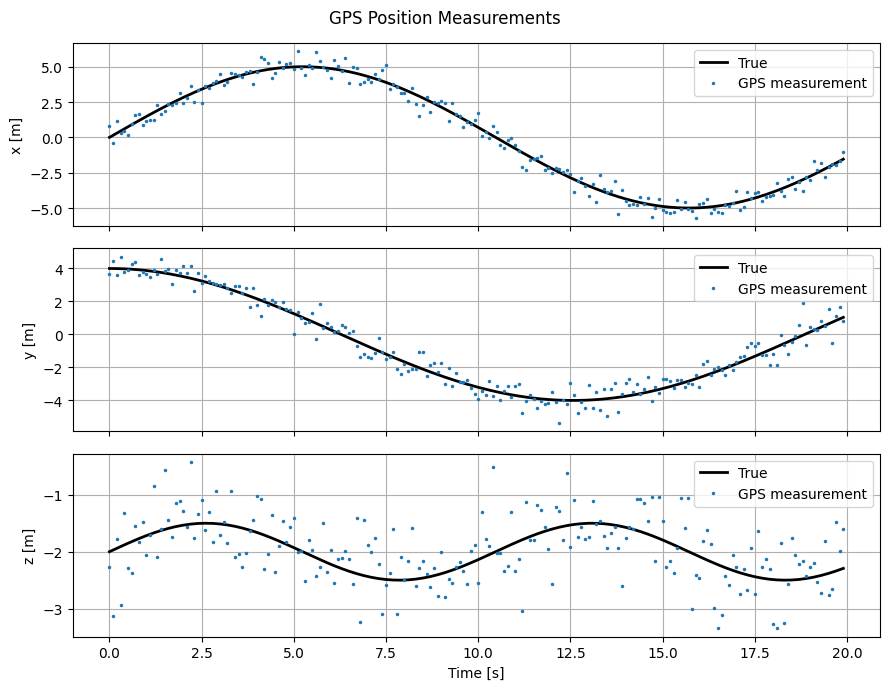

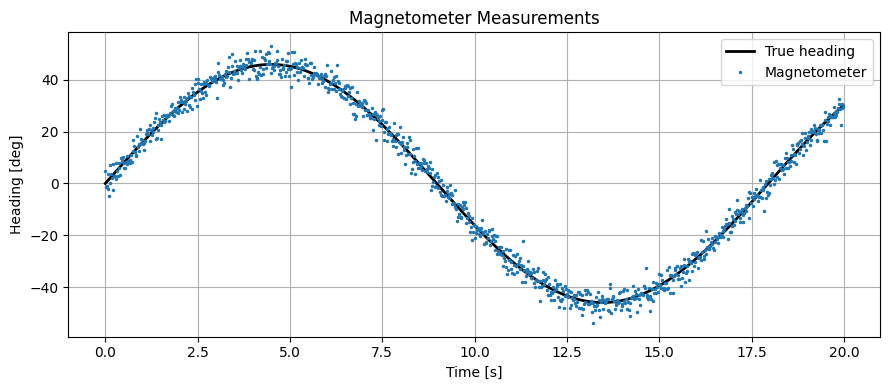

In [2]:
imu.demo();
gps.demo();
magnetometer.demo();